In [58]:
class Microwave:
    def __init__(self, brand : str, power_rating : str) -> None:
        self.brand = brand
        self.power_rating = power_rating
        self.turned_on = False
    
    def turn_on(self) -> None:
        if self.turned_on:
            print(f'Microwave ({self.brand}) is already turned on.')
        else:
            self.turned_on = True
            print(f'Microwave ({self.brand}) is Now turned on.')

    def turn_off(self) -> None:
        if self.turned_on:
            self.turned_on = False
            print(f'Microwave ({self.brand}) is now turned off.')
        else:
            print(f'Microwave ({self.brand}) is already turned off.')

    def run(self, seconds:int) -> None:
        if self.turned_on:
            print(f'Running ({self.brand}) for {seconds} seconds')
        else:
            print(f'Turn on your microwave first')

    def __add__(self, other):
        return f'{self.brand} + {other.brand}'
    
    def __mul__(self, other):
        return f'{self.brand} * {other.brand}'
    
    def __str__(self) -> str:
        return f'{self.brand} (Rating : {self.power_rating})'
    
    def __repr__(self) -> str:
        return f'Microwave(brand : {self.brand} , power_rating : {self.power_rating})'






smeg: Microwave = Microwave(brand = 'Smeg', power_rating='B')


bosch: Microwave = Microwave(brand = 'Bosch', power_rating = 'A')

print(smeg + bosch)
print(smeg + bosch)

print(repr(smeg))
print(bosch)



Smeg + Bosch
Smeg + Bosch
Microwave(brand : Smeg , power_rating : B)
Bosch (Rating : A)


In [71]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        out =  Value(self.data + other.data, (self, other), '+')
        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self,other), '*')
        return out

In [79]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0,label = 'f')
L = d*f; L.label = 'L'
L

Value(data=-8.0)

In [ ]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes ,edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir' : 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,  create a rectangular ('record') node for it
        dot.node(name = uid, label= "{ %s | data %.4f}" % (n.label, n.data), shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot 

            



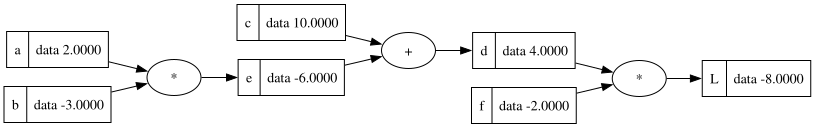

In [81]:
draw_dot(L)